# Práctica Evaluable - Unidad 3  
## Generador de Titulares con Mini-GPT en TensorFlow/Keras

Implementación limpia de un modelo autoregresivo a nivel de carácter para generar titulares en español.

## Parte 1. Preparación del entorno

Se configura el entorno, se fija semilla para reproducibilidad, se verifica la GPU y se carga el corpus de titulares.

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt



SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

DATA_PATH = Path("titulares.txt")

if not DATA_PATH.exists():
    try:
        import gdown
    except ImportError:
        !pip -q install gdown
        import gdown

    gdown.download(
        id="199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN",
        output=str(DATA_PATH),
        quiet=False,
    )

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Caracteres totales: {len(text):,}")
print("Primeros 500 caracteres:")
print(text[:500])

2026-03-08 23:22:52.052588: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 23:22:52.639071: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 23:22:54.176189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.20.0
Keras: 3.13.2
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Caracteres totales: 60,438
Primeros 500 caracteres:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


## Parte 2. Tokenización a nivel de carácter

Cada carácter se convierte en un índice entero. Se mantiene el enfoque pedido por la consigna y se construyen funciones de codificación y decodificación.

In [2]:
vocab = sorted(set(text))
vocab_size = len(vocab)

char_to_idx = {ch: idx for idx, ch in enumerate(vocab)}
idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)

print(f"Vocabulario: {vocab_size} caracteres únicos")
print("Muestra de vocabulario:", vocab[:20])

sample_text = text[:20]
sample_ids = encode(sample_text)
print("Texto de prueba:", repr(sample_text))
print("IDs:", sample_ids)
print("Reconstrucción:", repr(decode(sample_ids)))

Vocabulario: 33 caracteres únicos
Muestra de vocabulario: ['\n', ' ', '1', '2', '3', '4', '7', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']
Texto de prueba: 'nueva ley de energia'
IDs: [21, 28, 12, 29, 8, 1, 19, 12, 31, 1, 11, 12, 1, 12, 21, 12, 25, 14, 16, 8]
Reconstrucción: 'nueva ley de energia'


## Parte 3. Preparación de datos

Se generan pares `(X, y)` para modelado autoregresivo: la entrada es una ventana de longitud fija y la salida es la misma ventana desplazada un paso.
Además, se separa entrenamiento y validación para monitorear mejor la convergencia.

In [3]:
SEQ_LENGTH = 80
BATCH_SIZE = 64
VAL_SPLIT = 0.10
SHUFFLE_BUFFER = 10_000

tokens = np.array(encode(text), dtype=np.int32)

def crear_secuencias(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        chunk = tokens[i : i + seq_len + 1]
        X.append(chunk[:-1])
        y.append(chunk[1:])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X, y = crear_secuencias(tokens, SEQ_LENGTH)

num_samples = len(X)
num_val = max(1, int(num_samples * VAL_SPLIT))
num_train = num_samples - num_val

X_train, X_val = X[:num_train], X[num_train:]
y_train, y_val = y[:num_train], y[num_train:]

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(SHUFFLE_BUFFER, seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

I0000 00:00:1773008575.783587    1601 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9515 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


X_train: (54323, 80) y_train: (54323, 80)
X_val: (6035, 80) y_val: (6035, 80)


## Parte 4. Componentes del Transformer

Se implementan embeddings de token y posición, junto con un bloque Transformer decoder-only con atención causal, residuals, normalización y red feed-forward.

In [4]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, dropout=0.1):
        super().__init__()
        self.maxlen = maxlen
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        x = self.token_emb(x)
        x = x * tf.math.sqrt(tf.cast(self.embed_dim, tf.float32))
        x = x + self.pos_emb(positions)
        return self.dropout(x, training=training)

    def get_config(self):
        return {
            "maxlen": self.maxlen,
            "embed_dim": self.embed_dim,
            "token_emb": keras.saving.serialize_keras_object(self.token_emb),
            "pos_emb": keras.saving.serialize_keras_object(self.pos_emb),
        }


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim debe ser divisible por num_heads")

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout

        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout,
        )
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation=tf.nn.gelu),
                layers.Dropout(dropout),
                layers.Dense(embed_dim),
            ]
        )
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_output = self.att(
            query=x,
            value=x,
            key=x,
            use_causal_mask=True,
            training=training,
        )
        x = self.norm1(x + self.dropout(attn_output, training=training))

        ffn_output = self.ffn(x, training=training)
        return self.norm2(x + self.dropout(ffn_output, training=training))

## Parte 5. Modelo completo

Se construye un Mini-GPT decoder-only. La salida son logits sobre el vocabulario en cada posición.

In [5]:
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_BLOCKS = 4
DROPOUT = 0.15

def crear_modelo(
    seq_length=SEQ_LENGTH,
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS,
    dropout=DROPOUT,
):
    inputs = layers.Input(shape=(None,), dtype=tf.int32)
    x = TokenAndPositionEmbedding(seq_length, vocab_size, embed_dim, dropout=dropout)(inputs)

    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout=dropout)(x)

    logits = layers.Dense(vocab_size, name="logits")(x)
    return keras.Model(inputs=inputs, outputs=logits, name="mini_gpt_char")

model = crear_modelo()
model.summary()

Model: "mini_gpt_char"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, None, 128)      │        14,464 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, None, 128)      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, None, 128)      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, None, 128)      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, None, 128)      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, None, 33)       │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,641 (2.09 MB)

 Trainable params: 548,641 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

## Parte 6. Entrenamiento

Se usa `SparseCategoricalCrossentropy(from_logits=True)` para mayor estabilidad numérica.
Los callbacks guardan el mejor modelo, reducen la tasa de aprendizaje y detienen el entrenamiento cuando deja de mejorar.

In [6]:
optimizer = keras.optimizers.Adam(
    learning_rate=3e-4,
    beta_1=0.9,
    beta_2=0.95,
    clipnorm=1.0,
)

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "mini_gpt_best.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30


2026-03-08 23:23:02.754480: I external/local_xla/xla/service/service.cc:163] XLA service 0x7cd26c002240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-08 23:23:02.754520: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2026-03-08 23:23:02.960867: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-08 23:23:03.395318: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-08 23:23:04.264039: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-08 23:23:05.150761: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered o

  2/849 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.0284 - loss: 4.2277   

I0000 00:00:1773008594.736610    1695 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


838/849 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2743 - loss: 2.2891

2026-03-08 23:23:20.147618: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-08 23:23:21.681004: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 23:23:21.681158: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 23:23:21.681269: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none

849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2748 - loss: 2.2867

2026-03-08 23:23:31.028030: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-08 23:23:31.253961: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_38', 4 bytes spill stores, 4 bytes spill loads

2026-03-08 23:23:32.822658: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-08 23:23:32.933164: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08


Epoch 1: val_loss improved from None to 1.48597, saving model to mini_gpt_best.weights.h5

Epoch 1: finished saving model to mini_gpt_best.weights.h5
849/849 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.3148 - loss: 2.1052 - val_accuracy: 0.5131 - val_loss: 1.4860 - learning_rate: 3.0000e-04
Epoch 2/30
846/849 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4387 - loss: 1.7522
Epoch 2: val_loss improved from 1.48597 to 0.72547, saving model to mini_gpt_best.weights.h5

Epoch 2: finished saving model to mini_gpt_best.weights.h5
849/849 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5057 - loss: 1.5442 - val_accuracy: 0.7812 - val_loss: 0.7255 - learning_rate: 3.0000e-04
Epoch 3/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5560 - loss: 1.4143
Epoch 3: val_loss improved from 0.72547 to 0.49529, saving model to mini_gpt_best.weights.h5

Epoch 3: finished saving model to mini_gpt_best.weights.h5
849/849 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6138 - loss: 1.2226 - va

## Parte 6.1. Curvas de entrenamiento

Se visualizan pérdida y precisión en entrenamiento y validación para documentar el comportamiento del modelo.

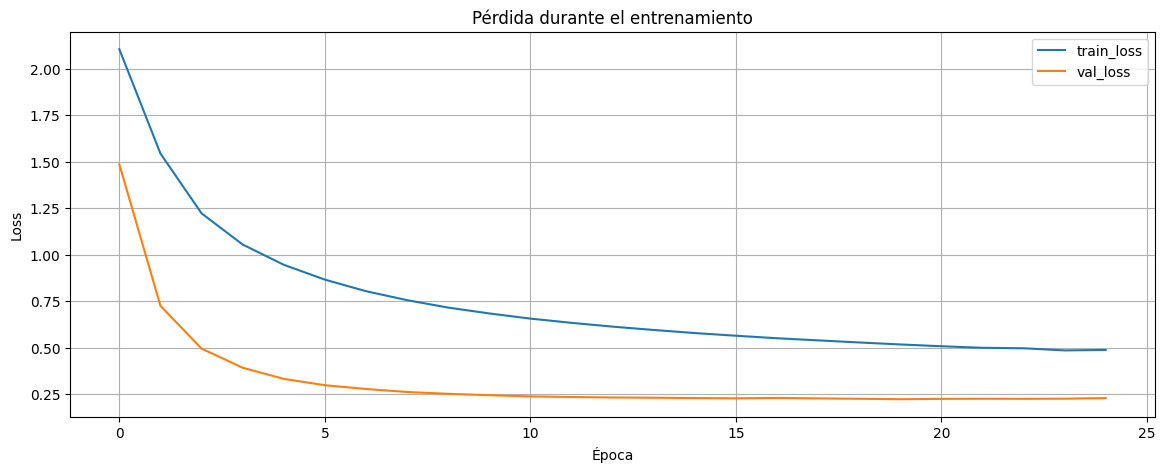

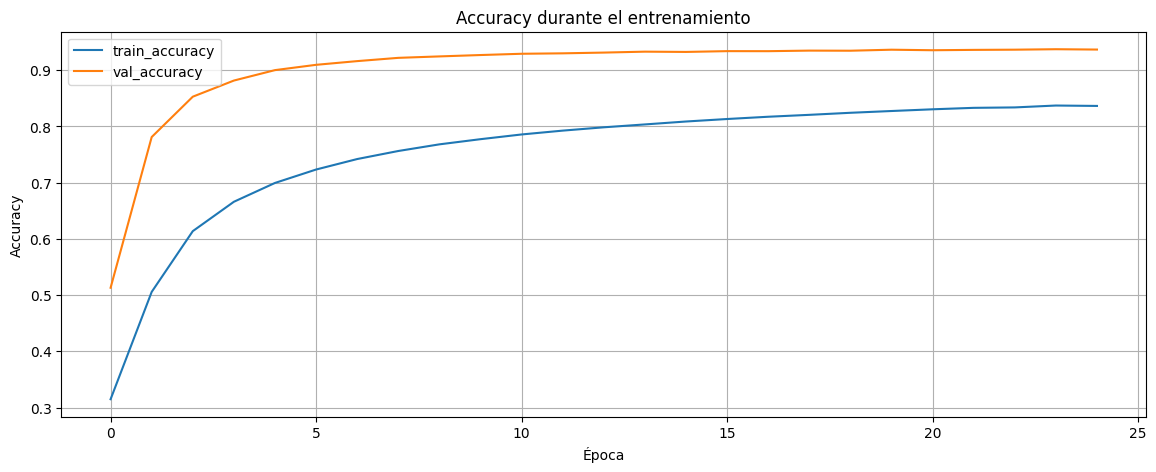

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

## Parte 7. Generación de texto

La generación es autoregresiva. Se permite controlar temperatura y `top_k` para estabilizar el muestreo.

In [8]:
def sample_from_logits(logits, temperature=1.0, top_k=None):
    logits = tf.convert_to_tensor(logits, dtype=tf.float32)

    temperature = max(float(temperature), 1e-5)
    logits = logits / temperature

    if top_k is not None:
        top_k = int(top_k)
        values, _ = tf.math.top_k(logits, k=min(top_k, logits.shape[-1]))
        min_topk = values[-1]
        logits = tf.where(logits < min_topk, tf.fill(tf.shape(logits), -1e9), logits)

    sample = tf.random.categorical(logits[tf.newaxis, :], num_samples=1)
    return int(sample[0, 0].numpy())


def limpiar_prompt(prompt):
    return "".join(ch for ch in prompt if ch in char_to_idx)


def generar_texto(
    model,
    inicio,
    longitud=120,
    temperatura=1.0,
    top_k=20,
    stop_on_newline=True,
):
    prompt = limpiar_prompt(inicio)
    if not prompt:
        raise ValueError("El texto inicial no contiene caracteres presentes en el vocabulario.")

    generado = encode(prompt)

    for _ in range(longitud):
        contexto = generado[-SEQ_LENGTH:]
        x = tf.constant([contexto], dtype=tf.int32)

        logits = model(x, training=False)[0, -1, :]
        next_idx = sample_from_logits(logits, temperature=temperatura, top_k=top_k)
        generado.append(next_idx)

        if stop_on_newline and idx_to_char[next_idx] == "\n":
            break

    return decode(generado)


print("=== Temperatura 0.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=0.5, top_k=10))

print("\n=== Temperatura 1.0 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.0, top_k=20))

print("\n=== Temperatura 1.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.5, top_k=30))

=== Temperatura 0.5 ===
el gobierno urbano mas sostenible


=== Temperatura 1.0 ===
el gobierno con estilo y conciencia


=== Temperatura 1.5 ===
el gobierno urbano guarderro



## Parte 7.1. Experimentación adicional

Se prueban distintos comienzos y varias temperaturas para comparar coherencia y diversidad.

In [10]:
inicios = [
    "la economia ",
    "un nuevo ",
    "el presidente ",
    "argentina ",
    "se espera ",
    "el congreso ",
    "la selección ",
]

temperaturas = [0.5, 0.8, 1.0, 1.3]

for inicio in inicios:
    print("=" * 80)
    print("Inicio:", repr(inicio))
    for temp in temperaturas:
        salida = generar_texto(model, inicio, longitud=100, temperatura=temp, top_k=20)
        print(f"temp={temp}: {salida}")
    print()

Inicio: 'la economia '
temp=0.5: la economia con la accion y la concienciacion

temp=0.8: la economia hacia la felicidad

temp=1.0: la economia agricola

temp=1.3: la economia de precision


Inicio: 'un nuevo '
temp=0.5: un nuevo hiperconectado

temp=0.8: un nuevo hiperconectado

temp=1.0: un nuevo positivo en la vida cotidiana

temp=1.3: un nuevo atomar las ciudades verdes y habitables


Inicio: 'el presidente '
temp=0.5: el presidente de la moda

temp=0.8: el presidente de las historias reales en la pantallla

temp=1.0: el presidente de cambio social

temp=1.3: el presidente de la resiliencia y el optimismo


Inicio: 'argentina '
temp=0.5: argentina en la era digital protegiendo nuestros oceanos

temp=0.8: argentina vertical

temp=1.0: argentina del futuro ia

temp=1.3: argentina para el autocuidado y el auge de los ecosistemas marinos protegiendo nuestros oceanos


Inicio: 'se espera '
temp=0.5: se espera a la accion y la reflexion

temp=0.8: se espera el autocuidado y la gestion de

## Análisis y reflexión

### Estructura de la entrega

Durante el desarrollo del ejercicio se construyeron **dos versiones del modelo**:

- **`ejercicio.ipynb`**: implementación inicial siguiendo directamente la consigna del ejercicio.
- **`mini_gpt_mejorado.ipynb`**: versión refactorizada y más robusta del modelo, donde se mejoraron aspectos de arquitectura, entrenamiento, generación y documentación.

La entrega final se apoya conceptualmente en **ambas versiones**.  
El notebook original permite observar el desarrollo base del ejercicio, mientras que el notebook mejorado muestra una implementación más estable y técnicamente más sólida del mismo modelo Mini-GPT.

Las mejoras principales de la segunda versión incluyen:

- mejor organización y claridad del código
- implementación más correcta del bloque Transformer
- uso adecuado de `key_dim` en la atención multi-cabeza
- uso de `use_causal_mask=True` para garantizar causalidad
- entrenamiento más estable usando logits
- incorporación de validación (`train / validation split`)
- callbacks más completos para control del entrenamiento
- generación de texto con `temperature` y `top_k`
- documentación más detallada del funcionamiento del modelo

De esta forma se conserva el desarrollo original del ejercicio y se presenta también una versión más defendible desde el punto de vista técnico.

---

# Qué hace cada parte del notebook

### 1. Preparación del entorno
Se importan TensorFlow, Keras, NumPy y Matplotlib.  
También se fija una semilla aleatoria para mejorar la reproducibilidad del entrenamiento y de los experimentos de generación.  

El dataset de titulares se descarga automáticamente si no se encuentra localmente y luego se carga como una sola cadena de texto.

---

### 2. Tokenización por carácter
Se construye un vocabulario con todos los caracteres únicos presentes en el corpus.

Se generan dos estructuras principales:

- `char_to_idx`: convierte caracteres a índices
- `idx_to_char`: reconstruye texto desde índices

Este enfoque mantiene el problema completamente visible a nivel de implementación.  
La desventaja es que las secuencias se vuelven más largas y el modelo debe aprender palabras y estructuras lingüísticas desde unidades muy pequeñas.

---

### 3. Preparación de datos
El modelo se entrena utilizando **ventanas deslizantes de longitud fija**.

Para cada ventana:

- **Entrada (X)**: los primeros `SEQ_LENGTH` caracteres
- **Etiqueta (y)**: la misma secuencia desplazada una posición

Esto permite que el modelo aprenda a **predecir el siguiente carácter dado el contexto previo**.

En la versión mejorada también se incluye una **separación entre entrenamiento y validación**, lo cual permite medir generalización y hace el experimento más defendible académicamente.

---

### 4. Embeddings
La capa `TokenAndPositionEmbedding` transforma los índices de caracteres en vectores densos.

Cada token embedding se combina con un **embedding posicional aprendido**, lo que permite que el modelo conserve información sobre el orden dentro de la secuencia.

Esto es esencial porque los Transformers no tienen recurrencia.

También se añade **dropout** para mejorar la regularización del modelo.

---

### 5. Bloque Transformer
Cada bloque Transformer contiene:

- **Multi-Head Self Attention con máscara causal**
- **Feed Forward Network**
- **Conexiones residuales**
- **Layer Normalization**

La **máscara causal** garantiza que el modelo solo pueda utilizar información del pasado, evitando ver tokens futuros.

La red feed-forward agrega capacidad no lineal después de la atención.

Las conexiones residuales y normalización ayudan a estabilizar el entrenamiento.

En la versión mejorada se corrigieron detalles importantes:

- `key_dim = embed_dim // num_heads`
- uso directo de `use_causal_mask=True`
- activación GELU en la red feed-forward

---

### 6. Modelo completo
El modelo implementado es un **Transformer decoder-only**, equivalente conceptualmente a un GPT pequeño.

Se apilan varios bloques Transformer y la salida final es una capa densa que produce **logits para cada carácter del vocabulario**.

En la versión mejorada no se aplica softmax dentro del modelo, lo que mejora la estabilidad numérica durante el entrenamiento.

---

### 7. Entrenamiento
El entrenamiento utiliza:

- optimizador **Adam**
- pérdida **SparseCategoricalCrossentropy(from_logits=True)**
- **gradient clipping** con `clipnorm`

Además se agregan callbacks:

- **ModelCheckpoint** para guardar el mejor modelo
- **EarlyStopping** para detener el entrenamiento si deja de mejorar
- **ReduceLROnPlateau** para reducir la tasa de aprendizaje cuando la validación se estanca

Esto hace que el entrenamiento sea más estable y controlado.

---

### 8. Generación de texto
La generación se realiza de forma **autoregresiva**.

El modelo:

1. recibe el contexto actual
2. predice logits del siguiente carácter
3. se muestrea un nuevo carácter según temperatura
4. se agrega al contexto
5. el proceso se repite

Se experimenta con:

- **temperature**
- **top_k sampling**

Temperaturas bajas generan texto más conservador, mientras que temperaturas altas aumentan la diversidad.

---

# Comparativa entre el modelo original y el modelo mejorado

| Aspecto | Modelo original | Modelo mejorado |
|-------|-------|-------|
| Organización del código | básica | más clara y modular |
| Implementación de atención | funcional pero menos precisa | implementación más estándar |
| Máscara causal | manual | `use_causal_mask=True` |
| Dimensión de atención | `key_dim` menos adecuada | `embed_dim // num_heads` |
| Estabilidad numérica | salida con softmax | entrenamiento con logits |
| Dataset | entrenamiento único | entrenamiento + validación |
| Control de entrenamiento | callbacks básicos | callbacks completos |
| Generación | sampling simple | temperatura + top_k |
| Documentación | básica | explicaciones detalladas |

En general, la segunda versión mantiene la misma idea del modelo, pero mejora la implementación técnica y la reproducibilidad del experimento.

---

# Observaciones sobre los resultados generados

Los experimentos de generación muestran comportamientos interesantes según la temperatura.

### Temperatura baja (0.5)

Los resultados tienden a ser más coherentes y sintácticamente correctos.

Ejemplos:

- *"la economia con la accion y la concienciacion"*
- *"se espera a la accion y la reflexion"*

Aquí el modelo prioriza los tokens más probables y reproduce estructuras muy comunes del corpus.

---

### Temperatura media (0.8 – 1.0)

Aparece mayor diversidad manteniendo cierta coherencia:

- *"la economia hacia la felicidad"*
- *"el presidente de cambio social"*
- *"argentina del futuro ia"*

Esto sugiere que el modelo ha aprendido patrones semánticos generales del corpus, como estructuras de titulares o frases nominales.

---

### Temperatura alta (1.3)

La diversidad aumenta, pero también aparecen errores o construcciones menos naturales:

- *"un nuevo atomar las ciudades verdes y habitables"*
- *"se espera un con mundo digital"*
- *"la seleccin recimiento positivo"*

Esto es esperable porque temperaturas altas aumentan la exploración del espacio de tokens.

---

# Sobre la visualización de precisión (accuracy)

En el notebook se incluyen gráficas de **loss** y **accuracy** durante el entrenamiento.  
La visualización de precisión se considera más honesta y útil por varias razones:

**a) Permite interpretar mejor el progreso del modelo**

La pérdida (cross-entropy) puede disminuir incluso cuando las predicciones aún no son correctas, ya que mide la distribución de probabilidad.  
La precisión, en cambio, refleja directamente **qué proporción de caracteres el modelo predice correctamente**.

**b) Facilita comparar entrenamiento y validación**

Al mostrar **accuracy de entrenamiento y de validación**, es posible observar si el modelo:

- mejora de forma consistente
- comienza a sobreajustarse
- mantiene un comportamiento similar entre ambos conjuntos

Esto ayuda a interpretar si el modelo realmente está aprendiendo patrones del lenguaje o simplemente memorizando.

**c) Hace más interpretable el comportamiento del modelo**

Para lectores que no están familiarizados con funciones de pérdida probabilísticas, la precisión ofrece una métrica más intuitiva:  
qué porcentaje de caracteres el modelo logra predecir correctamente.

Por estas razones, mostrar ambas métricas —pero especialmente **accuracy**— proporciona una visión más clara del desempeño del modelo durante el entrenamiento.

---

# Reflexión final

El modelo logra capturar patrones característicos de titulares en español, especialmente estructuras nominales cortas y expresiones frecuentes como:

- "la economía..."
- "el presidente..."
- "se espera..."
- "un nuevo..."

Esto demuestra que incluso un **Transformer pequeño entrenado a nivel de carácter** puede aprender regularidades sintácticas del lenguaje.

Sin embargo, existen limitaciones importantes:

- coherencia semántica limitada
- errores ortográficos ocasionales
- dependencia fuerte del prompt inicial
- dificultad para mantener consistencia en frases largas

Estas limitaciones se explican principalmente por:

- el tamaño reducido del corpus
- la tokenización por carácter
- la escala pequeña del modelo

A pesar de ello, el experimento es valioso porque permite observar claramente cómo un modelo tipo GPT aprende patrones lingüísticos a partir de texto crudo.

La versión mejorada del notebook refuerza la implementación y hace que el experimento sea más sólido desde una perspectiva técnica y académica.

---

# Limitaciones y posibles mejoras futuras

Aunque el modelo funciona correctamente para fines educativos, existen varias mejoras posibles que podrían explorarse en trabajos futuros:

**1. Tokenización subword**

Usar tokenización tipo BPE o WordPiece permitiría capturar unidades lingüísticas más grandes que un carácter, lo que suele mejorar la coherencia del texto generado.

**2. Corpus más grande**

Entrenar el modelo con un dataset más amplio permitiría aprender patrones semánticos más robustos y reducir errores en la generación.

**3. Modelos más profundos**

Aumentar el número de bloques Transformer o la dimensión de embeddings podría mejorar la capacidad representacional del modelo, aunque también aumentaría el costo computacional.

**4. Estrategias de muestreo más avanzadas**

Se podrían explorar técnicas como:

- nucleus sampling (top-p)
- penalización de repetición
- beam search adaptado a generación creativa

**5. Evaluación automática del texto**

Además de observar ejemplos generados, se podrían usar métricas automáticas de calidad del lenguaje o análisis de diversidad textual.

Estas extensiones permitirían transformar este ejercicio educativo en una base para experimentos más avanzados en modelos generativos de lenguaje.